# Caltech-101 Image Classification
## Step 4: Classical ML — SVM with HOG Features

**Method**: Support Vector Machine (RBF kernel) trained on HOG (Histogram of Oriented Gradients) features.

**Ablation study**: HOG features vs CNN features (frozen ResNet-18 embeddings)  
This isolates whether performance differences come from the **classifier** or the **features**.

**Prerequisites**: `shared_data.pkl` from Step 1.

In [1]:
# ── Imports
import pickle
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

# HOG feature extraction
from skimage.feature import hog
from skimage.transform import resize as sk_resize

# Classical ML
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)

# CNN feature extraction (frozen ResNet-18)
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility
SEED = 261
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

Using device: mps


In [3]:
# ── Load shared data from Step 1
with open("shared_data.pkl", "rb") as f:
    data = pickle.load(f)

train_paths  = data["train_paths"]
train_labels = data["train_labels"]
val_paths    = data["val_paths"]
val_labels   = data["val_labels"]
test_paths   = data["test_paths"]
test_labels  = data["test_labels"]
class_names  = data["class_names"]

NUM_CLASSES = len(class_names)
print(f"Classes: {NUM_CLASSES} | Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Classes: 101 | Train: 6073 | Val: 1302 | Test: 1302


In [5]:
# ── Configuration
IMG_SIZE     = 128   # resize all images to this before feature extraction
NUM_WORKERS  = 0     # Mac compatibility
BATCH_SIZE   = 64    # for CNN feature extraction only

# HOG parameters — tuned for 128×128 input
HOG_PARAMS = {
    "orientations" : 9,       # number of gradient orientation bins
    "pixels_per_cell": (8, 8),# each cell covers 8×8 pixels
    "cells_per_block": (2, 2),# normalization block = 2×2 cells
    "channel_axis"  : -1,     # last axis = RGB channels
}
# Resulting HOG feature vector length: 9 * (2*2) * ((128/8-1) * (128/8-1)) = 9*4*225 = 8100

# PCA components — reduces HOG dimensionality while retaining most variance
# Speeds up SVM training significantly
PCA_COMPONENTS = 512

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [7]:
# ── Feature Extractor 1: HOG
def extract_hog_features(image_paths, img_size=IMG_SIZE):
    """
    Load each image, resize to img_size×img_size, extract HOG descriptor.
    Returns a 2D numpy array of shape (N, hog_feature_dim).
    """
    features = []
    for i, path in enumerate(image_paths):
        # Load and resize image to fixed size
        img = np.array(Image.open(path).convert("RGB"))
        img = sk_resize(img, (img_size, img_size), anti_aliasing=True)  # float64 in [0,1]

        # Extract HOG: captures edge orientations in local regions
        feat = hog(img, **HOG_PARAMS)
        features.append(feat)

        if (i + 1) % 1000 == 0:
            print(f"  HOG extracted: {i+1}/{len(image_paths)}")

    return np.array(features)  # shape: (N, hog_dim)


print("Extracting HOG features...")
t0 = time.time()
X_train_hog = extract_hog_features(train_paths)
X_val_hog   = extract_hog_features(val_paths)
X_test_hog  = extract_hog_features(test_paths)
print(f"Done in {time.time()-t0:.1f}s")
print(f"HOG feature shape — Train: {X_train_hog.shape} | Val: {X_val_hog.shape} | Test: {X_test_hog.shape}")

Extracting HOG features...
  HOG extracted: 1000/6073
  HOG extracted: 2000/6073
  HOG extracted: 3000/6073
  HOG extracted: 4000/6073
  HOG extracted: 5000/6073
  HOG extracted: 6000/6073
  HOG extracted: 1000/1302
  HOG extracted: 1000/1302
Done in 49.2s
HOG feature shape — Train: (6073, 8100) | Val: (1302, 8100) | Test: (1302, 8100)


In [8]:
# ── Feature Extractor 2: CNN (frozen ResNet-18 embeddings)
# Use pretrained ResNet-18 as a fixed feature extractor (no fine-tuning)
# Remove the final classification layer → outputs 512-dim embedding per image
# This ablation tests: does a better feature extractor overcome SVM's limits?

class Caltech101Dataset(Dataset):
    """Minimal dataset for CNN feature extraction."""
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


def build_cnn_extractor():
    """ResNet-18 with final FC removed — outputs 512-dim feature vectors."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # nn.Sequential(*list(...)[:-1]) drops the final FC layer
    extractor = nn.Sequential(*list(model.children())[:-1])
    extractor.eval()  # freeze BatchNorm stats
    return extractor.to(DEVICE)


@torch.no_grad()
def extract_cnn_features(image_paths, labels):
    """
    Pass images through frozen ResNet-18, collect 512-dim embeddings.
    Returns numpy array of shape (N, 512).
    """
    tf = transforms.Compose([
        transforms.Resize((224, 224)),   # ResNet expects 224×224
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    dataset = Caltech101Dataset(image_paths, labels, transform=tf)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=False)
    extractor = build_cnn_extractor()
    all_feats = []
    for imgs, _ in loader:
        imgs  = imgs.to(DEVICE)
        feats = extractor(imgs)          # shape: (B, 512, 1, 1)
        feats = feats.squeeze(-1).squeeze(-1)  # → (B, 512)
        all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats)     # shape: (N, 512)


print("Extracting CNN features (frozen ResNet-18)...")
t0 = time.time()
X_train_cnn = extract_cnn_features(train_paths, train_labels)
X_val_cnn   = extract_cnn_features(val_paths,   val_labels)
X_test_cnn  = extract_cnn_features(test_paths,  test_labels)
print(f"Done in {time.time()-t0:.1f}s")
print(f"CNN feature shape — Train: {X_train_cnn.shape} | Val: {X_val_cnn.shape} | Test: {X_test_cnn.shape}")

Extracting CNN features (frozen ResNet-18)...
Done in 29.4s
CNN feature shape — Train: (6073, 512) | Val: (1302, 512) | Test: (1302, 512)


In [9]:
# ── SVM Pipeline builder
def build_svm_pipeline(use_pca=True, pca_components=PCA_COMPONENTS):
    """
    Build a sklearn Pipeline:
      1. StandardScaler  — zero mean, unit variance (critical for SVM)
      2. PCA             — dimensionality reduction (optional, speeds up SVM)
      3. SVC (RBF)       — main classifier

    C=10: regularization — higher C = less margin tolerance (tuned for Caltech-101)
    gamma='scale': kernel coefficient = 1/(n_features * X.var()) — auto-scaled
    decision_function_shape='ovr': one-vs-rest for multi-class (101 classes)
    """
    steps = [("scaler", StandardScaler())]
    if use_pca:
        steps.append(("pca", PCA(n_components=pca_components, random_state=SEED)))
    steps.append(("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        decision_function_shape="ovr",
        probability=True,   # enables predict_proba for top-5 accuracy
        random_state=SEED
    )))
    return Pipeline(steps)


# Ablation configs
ABLATION_CONFIGS = [
    {
        "name"      : "SVM_HOG",           # classical features
        "X_train"   : X_train_hog,
        "X_val"     : X_val_hog,
        "X_test"    : X_test_hog,
        "use_pca"   : True,                # HOG is high-dim → PCA helps
    },
    {
        "name"      : "SVM_CNN",           # learned features (ablation)
        "X_train"   : X_train_cnn,
        "X_val"     : X_val_cnn,
        "X_test"    : X_test_cnn,
        "use_pca"   : False,               # CNN features are already compact (512-dim)
    },
]

In [10]:
# ── Train SVM for each ablation config
# Note: SVM training on ~6300 samples with RBF kernel takes a few minutes
# No epochs here — SVM solves a convex optimization problem in one pass
trained_pipelines = {}

for config in ABLATION_CONFIGS:
    print(f"\n{'='*60}")
    print(f"Training: {config['name']}")
    print(f"{'='*60}")

    pipeline = build_svm_pipeline(use_pca=config["use_pca"])

    t0 = time.time()
    # SVM trains on train set only — no val set needed during training
    pipeline.fit(config["X_train"], train_labels)
    print(f"Training done in {time.time()-t0:.1f}s")

    # Quick val accuracy check
    val_acc = pipeline.score(config["X_val"], val_labels)
    print(f"Val Accuracy: {val_acc:.4f}")

    trained_pipelines[config["name"]] = {"pipeline": pipeline, "config": config}


Training: SVM_HOG
Training done in 43.0s
Val Accuracy: 0.6720

Training: SVM_CNN
Training done in 23.8s
Val Accuracy: 0.9339


In [11]:
# ── Evaluation helpers ─────────────────────────────────────────────────────────
def top5_accuracy(labels, probs):
    """Correct if true label appears in top-5 predicted classes."""
    top5    = np.argsort(probs, axis=1)[:, -5:]
    correct = sum(labels[i] in top5[i] for i in range(len(labels)))
    return correct / len(labels)


def full_evaluation(name, pipeline, X_test):
    """Compute and print all evaluation metrics on test set."""
    print(f"\n{'='*60}")
    print(f"Evaluation: {name}")
    print(f"{'='*60}")

    y_pred  = pipeline.predict(X_test)
    y_probs = pipeline.predict_proba(X_test)  # shape: (N, 101)
    y_true  = np.array(test_labels)

    acc  = accuracy_score(y_true, y_pred)
    top5 = top5_accuracy(y_true, y_probs)
    print(f"Overall Accuracy : {acc:.4f}")
    print(f"Top-5 Accuracy   : {top5:.4f}")

    p_mac, r_mac, f_mac, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
    p_wt,  r_wt,  f_wt,  _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    print(f"Macro    — P: {p_mac:.4f}  R: {r_mac:.4f}  F1: {f_mac:.4f}")
    print(f"Weighted — P: {p_wt:.4f}  R: {r_wt:.4f}  F1: {f_wt:.4f}")

    report = classification_report(y_true, y_pred, target_names=class_names,
                                   output_dict=True, zero_division=0)
    per_class_acc = {cls: report[cls]["recall"] for cls in class_names}
    worst5 = sorted(per_class_acc.items(), key=lambda x:  x[1])[:5]
    best5  = sorted(per_class_acc.items(), key=lambda x: -x[1])[:5]
    print(f"\nTop-5 best  classes: {best5}")
    print(f"Top-5 worst classes: {worst5}")

    return y_true, y_pred, {
        "acc": acc, "top5": top5,
        "macro_f1": f_mac, "weighted_f1": f_wt,
        "per_class_acc": per_class_acc
    }

In [12]:
# ── Run evaluation on all configs ─────────────────────────────────────────────
eval_results = {}

for name, obj in trained_pipelines.items():
    X_test  = obj["config"]["X_test"]
    y_true, y_pred, metrics = full_evaluation(name, obj["pipeline"], X_test)
    eval_results[name] = {"y_true": y_true, "y_pred": y_pred, "metrics": metrics}


Evaluation: SVM_HOG
Overall Accuracy : 0.6375
Top-5 Accuracy   : 0.8187
Macro    — P: 0.5884  R: 0.4512  F1: 0.4701
Weighted — P: 0.6614  R: 0.6375  F1: 0.6194

Top-5 best  classes: [('Faces_easy', 1.0), ('Motorbikes', 1.0), ('accordion', 1.0), ('windsor_chair', 1.0), ('airplanes', 0.9833333333333333)]
Top-5 worst classes: [('ant', 0.0), ('barrel', 0.0), ('mayfly', 0.0), ('octopus', 0.0), ('okapi', 0.0)]

Evaluation: SVM_CNN
Overall Accuracy : 0.9309
Top-5 Accuracy   : 0.9900
Macro    — P: 0.9164  R: 0.8879  F1: 0.8962
Weighted — P: 0.9365  R: 0.9309  F1: 0.9300

Top-5 best  classes: [('Faces', 1.0), ('Faces_easy', 1.0), ('Leopards', 1.0), ('Motorbikes', 1.0), ('accordion', 1.0)]
Top-5 worst classes: [('octopus', 0.4), ('chair', 0.4444444444444444), ('lobster', 0.5), ('mandolin', 0.5), ('water_lilly', 0.5)]


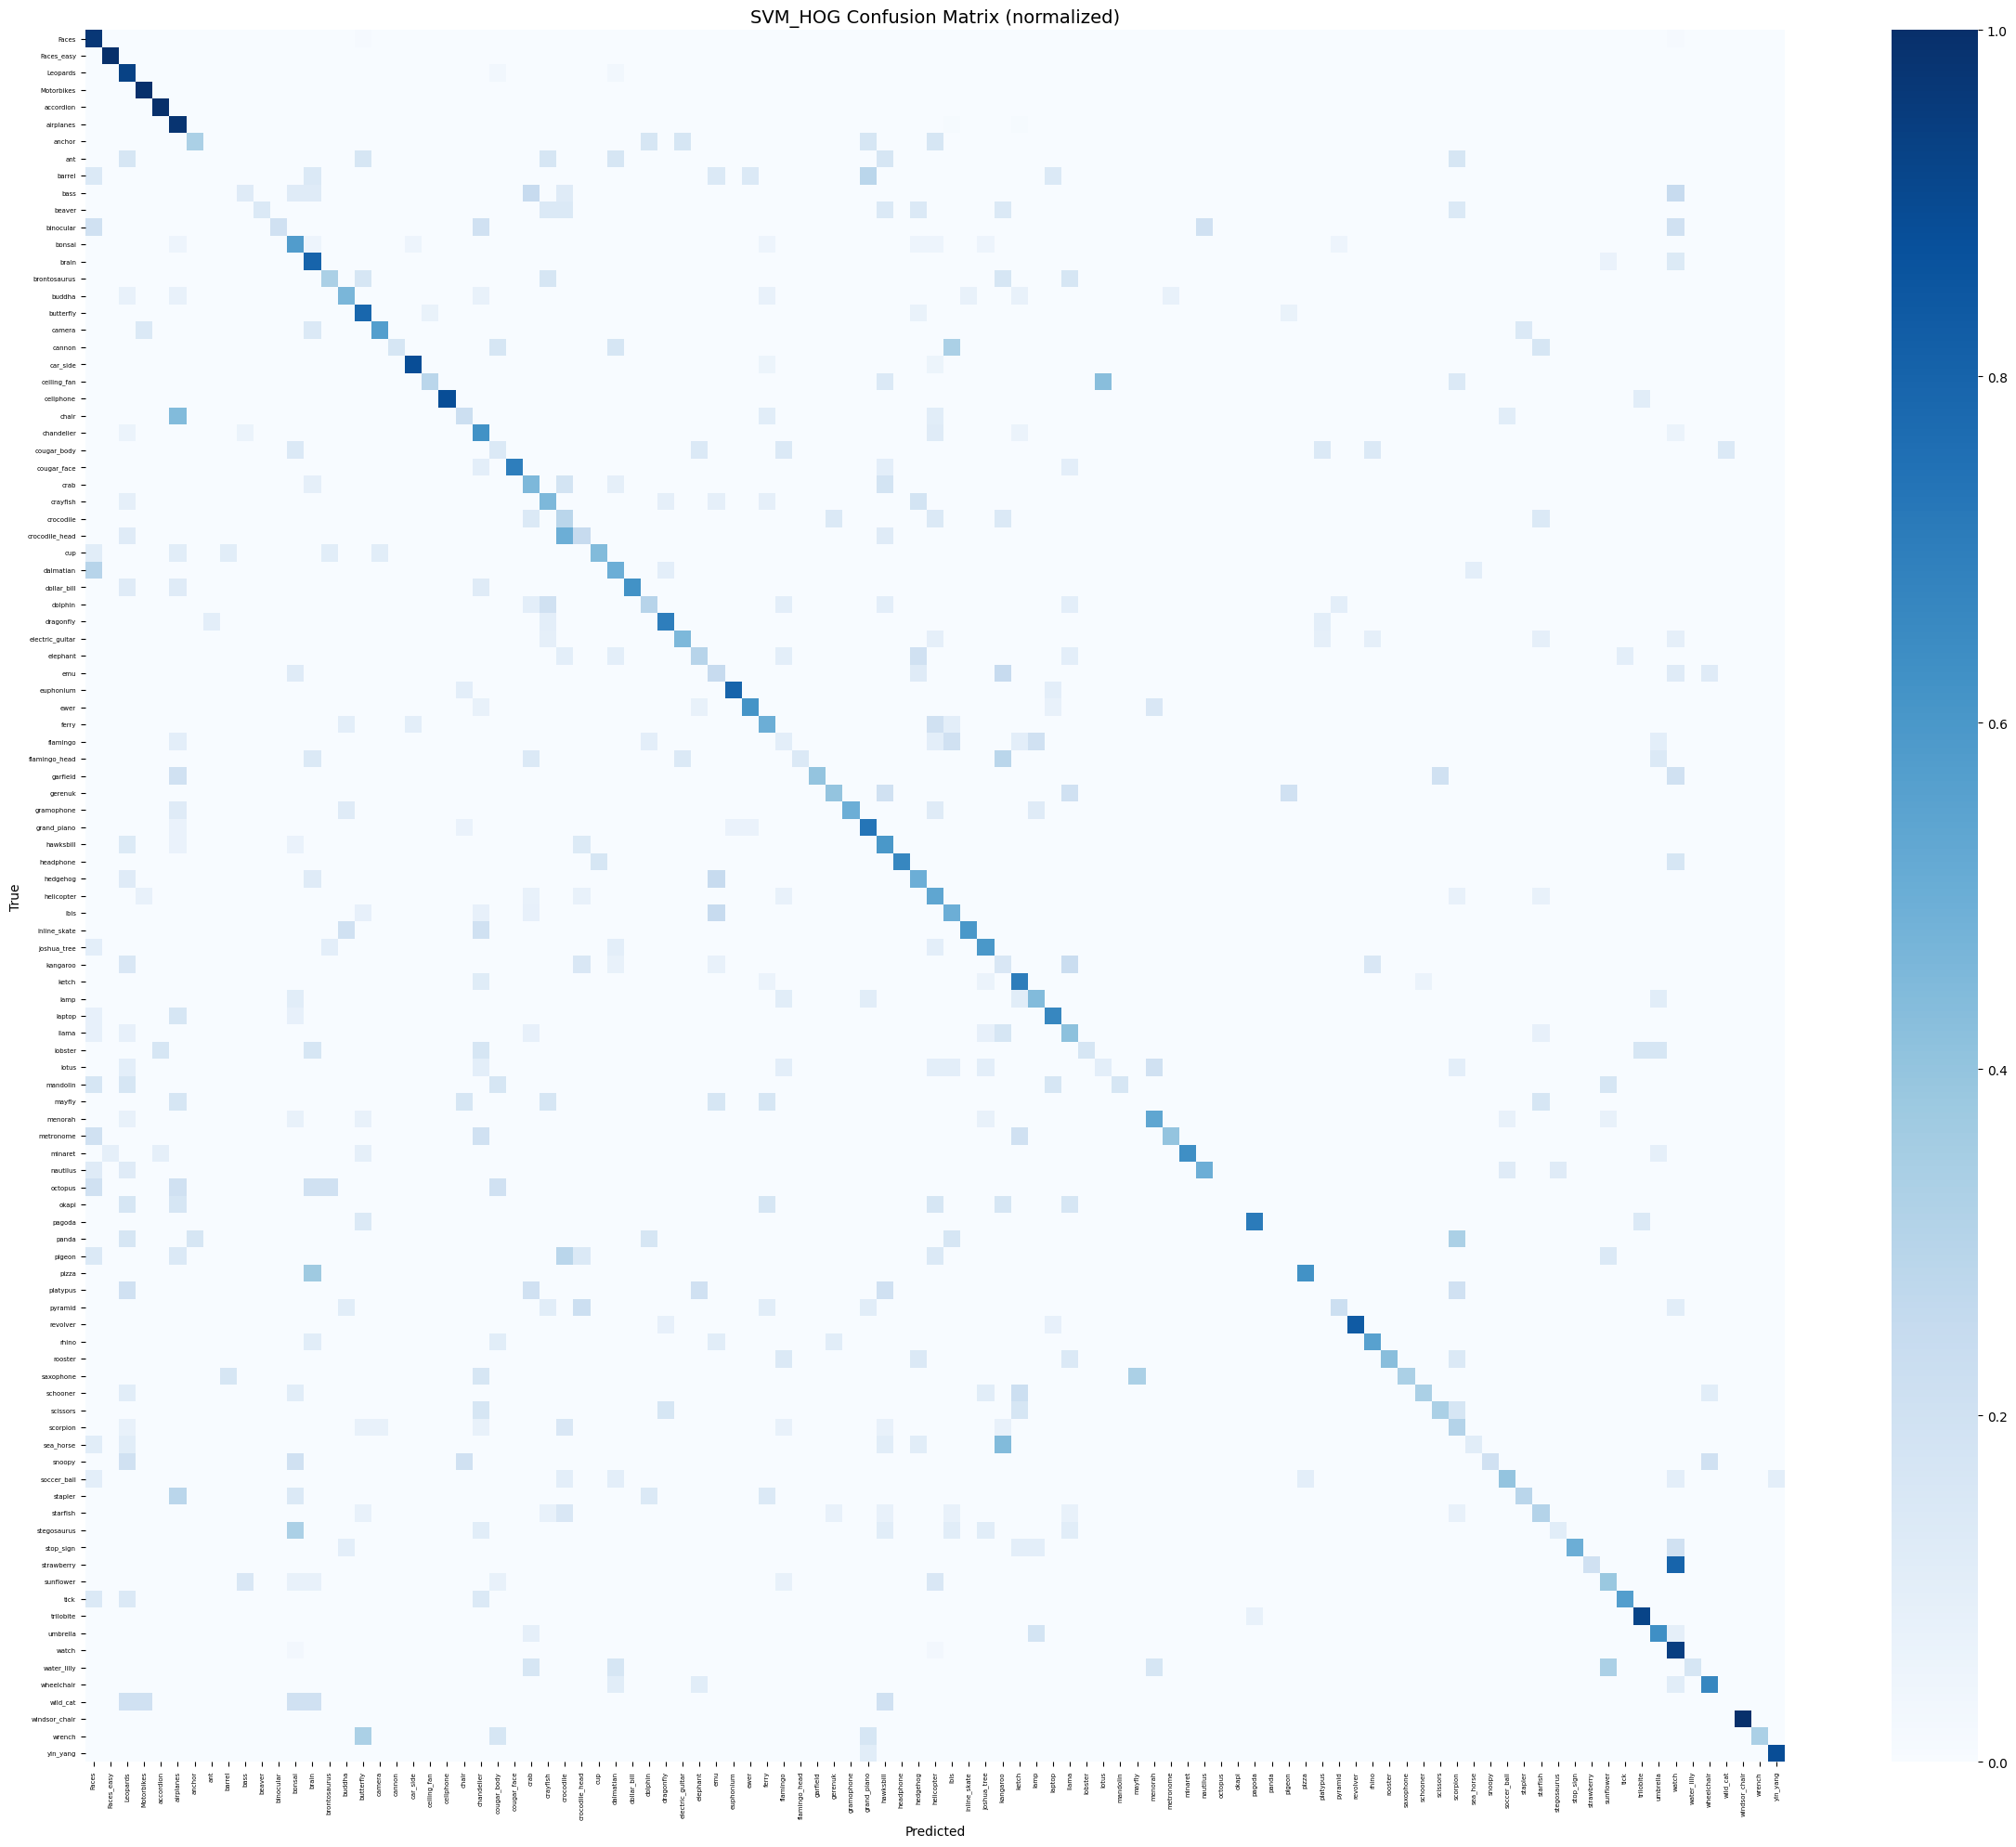

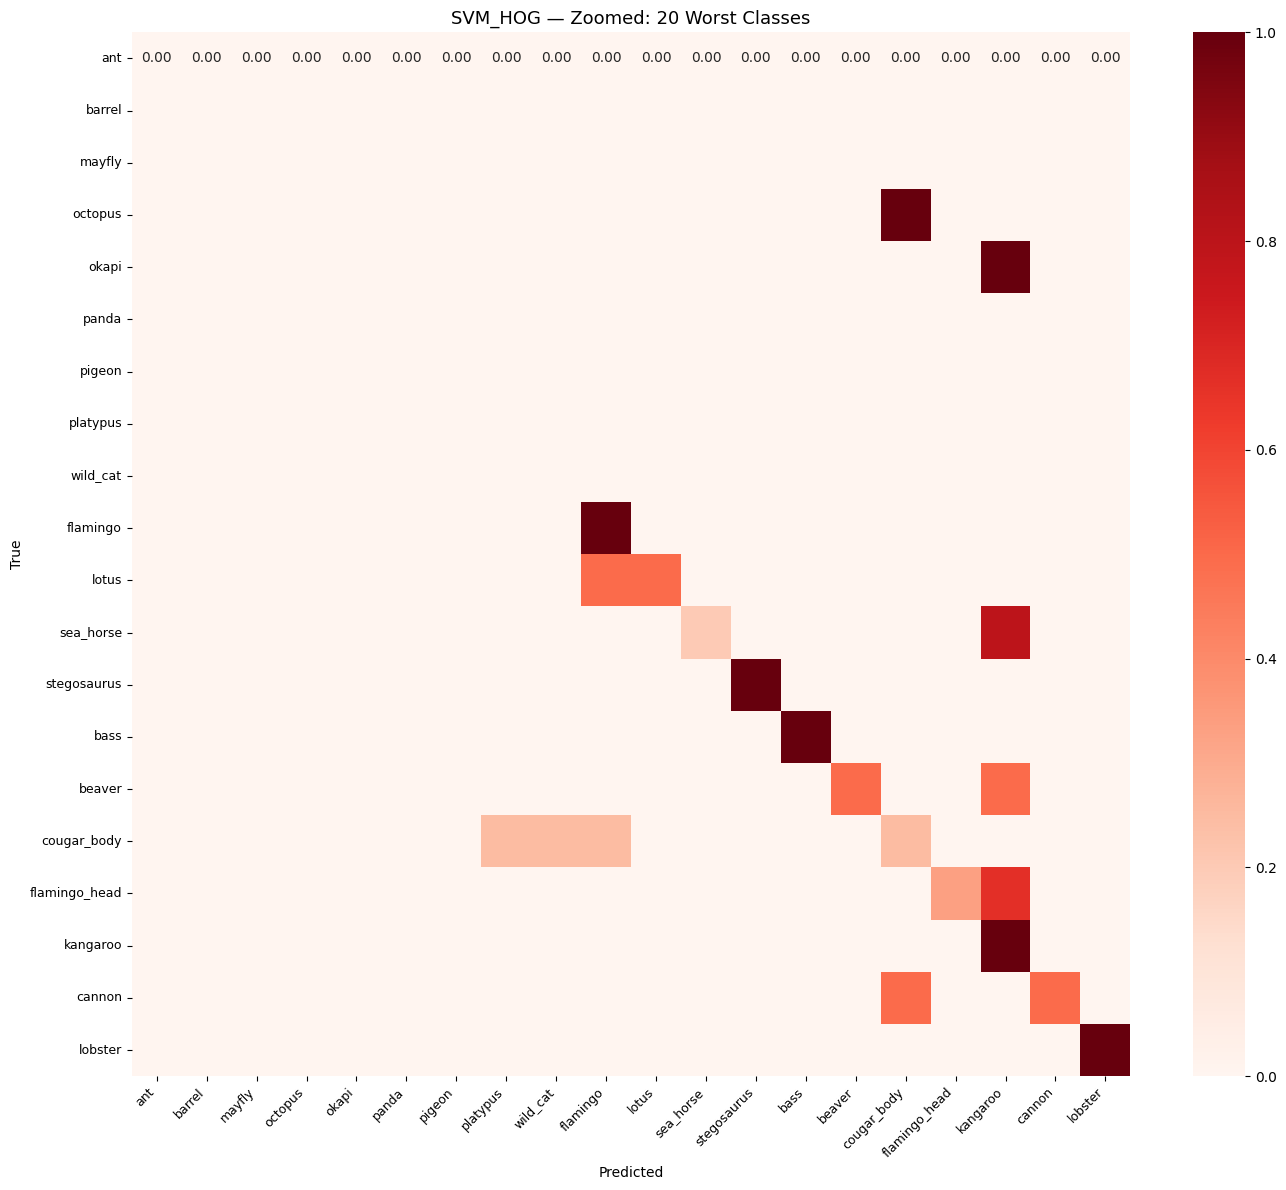

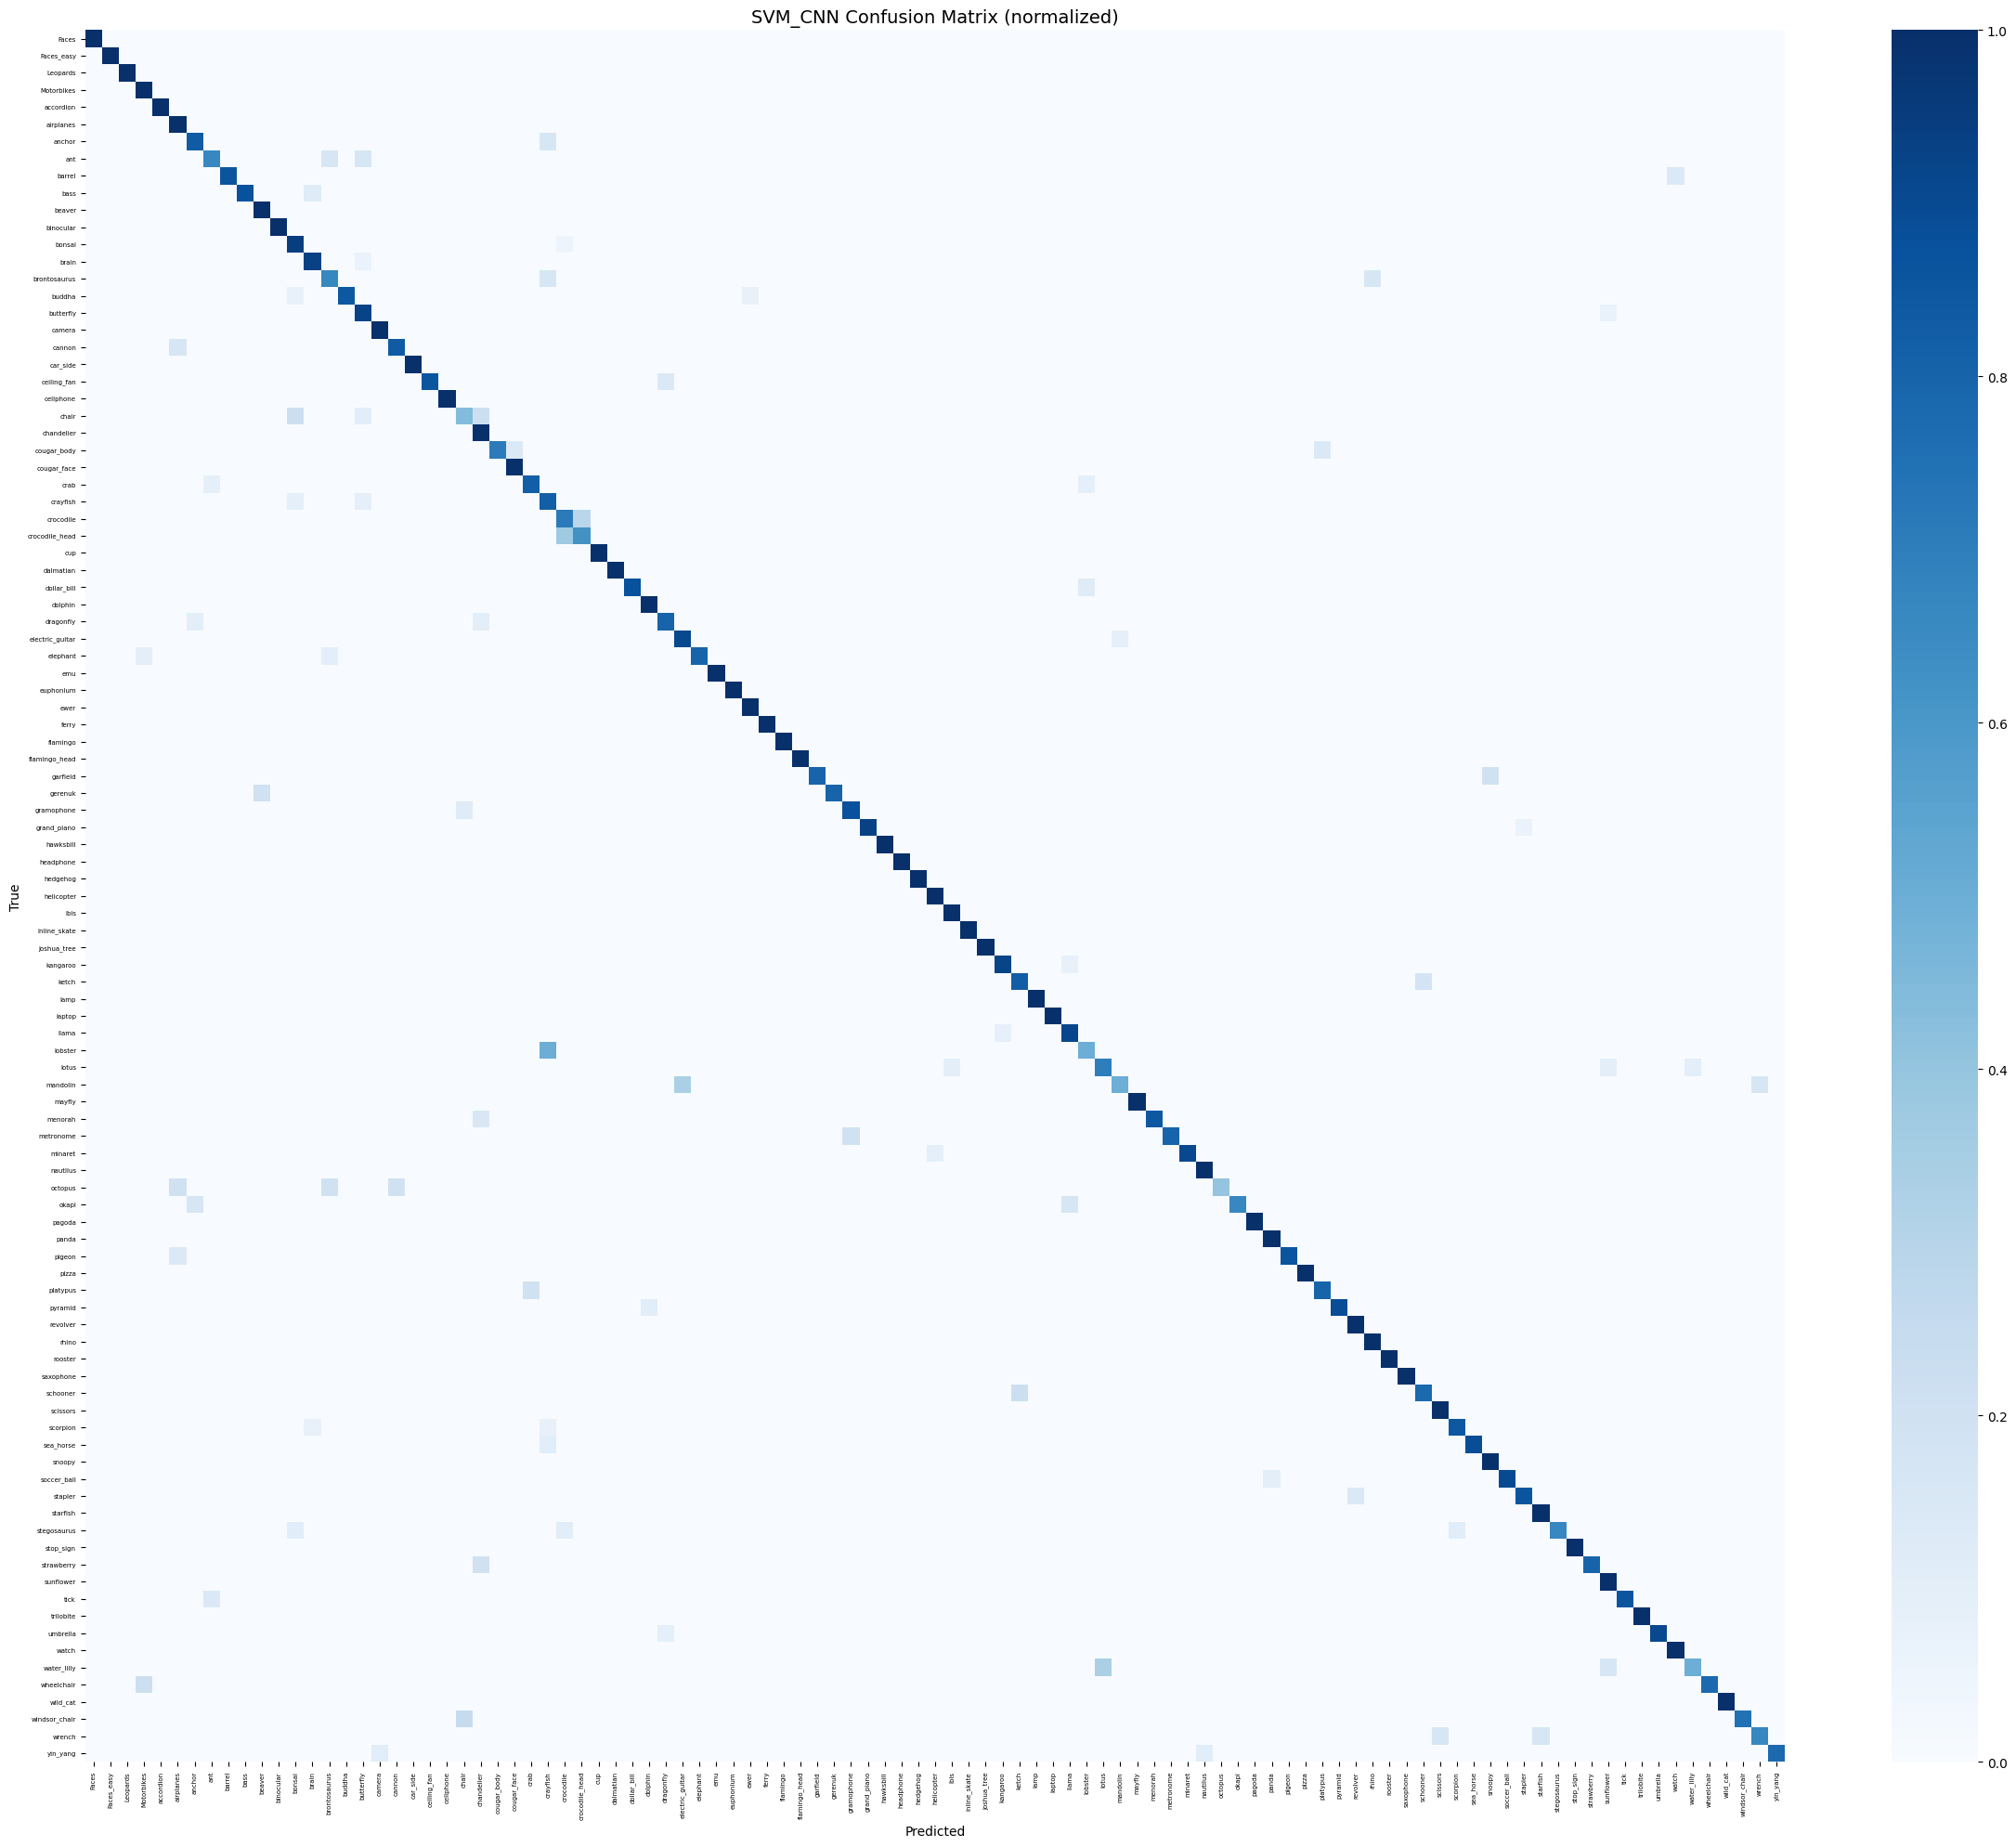

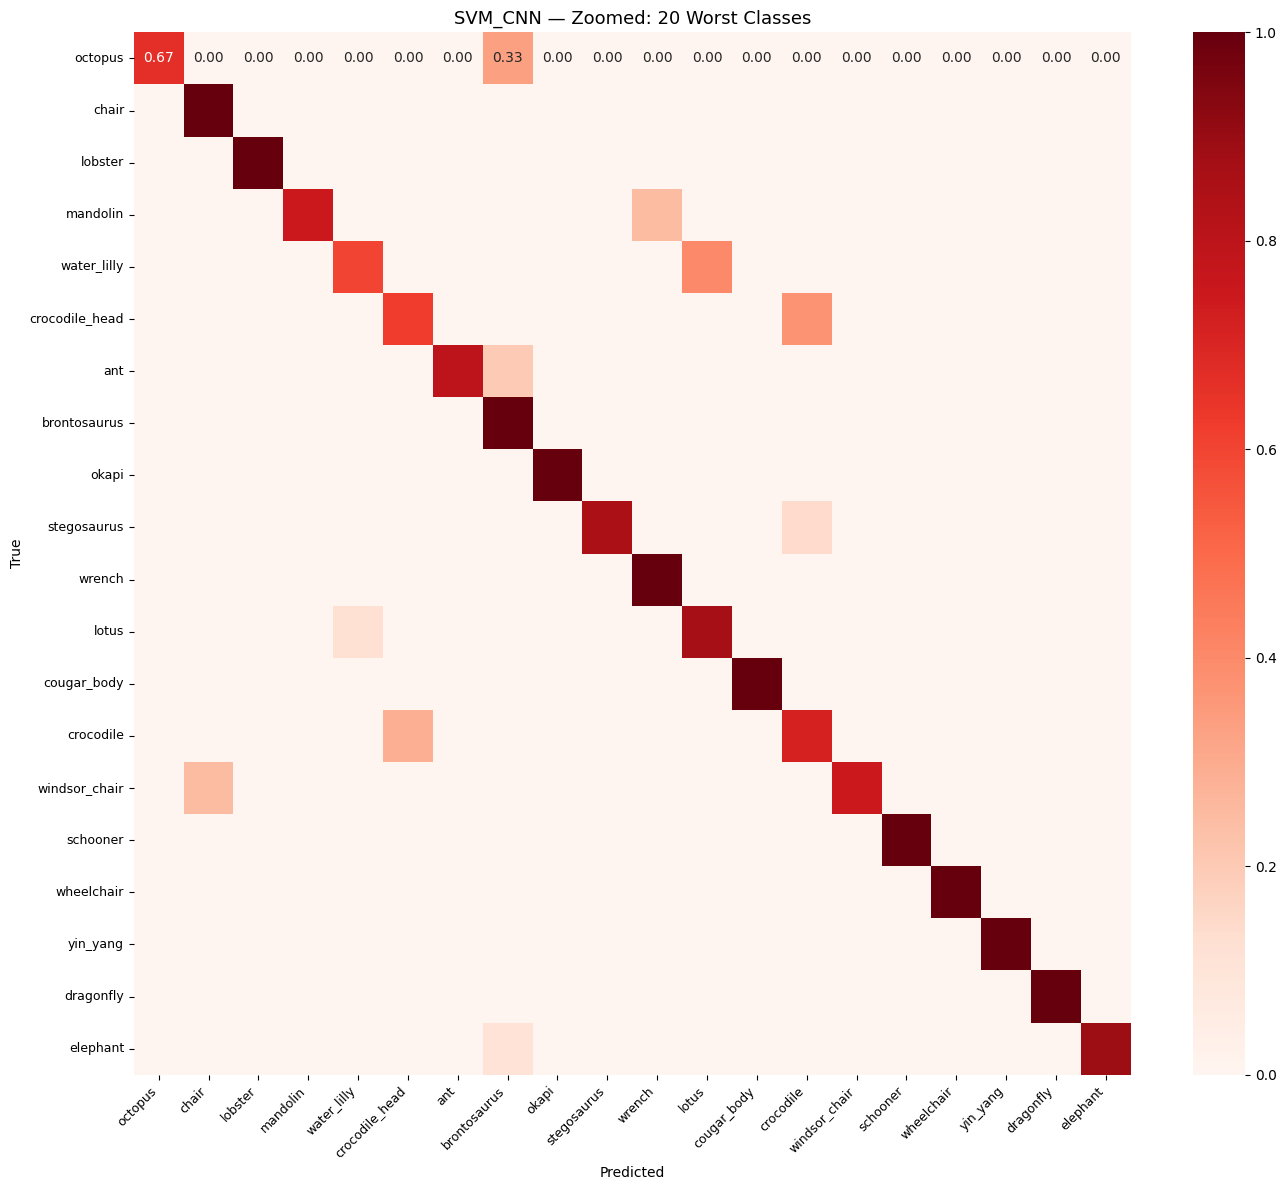

In [13]:
# ── Confusion matrices: full + zoomed worst classes ────────────────────────────
for name, res in eval_results.items():
    y_true = res["y_true"]
    y_pred = res["y_pred"]
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    # Full confusion matrix
    fig, ax = plt.subplots(figsize=(24, 20))
    sns.heatmap(cm_norm, ax=ax, cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, vmin=0, vmax=1)
    ax.set_title(f"{name} Confusion Matrix (normalized)", fontsize=14)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.xticks(rotation=90, fontsize=5); plt.yticks(fontsize=5)
    plt.tight_layout()
    plt.savefig(f"{name}_confusion_matrix.png", dpi=120, bbox_inches="tight")
    plt.show()

    # Zoomed: worst 20 classes
    per_class_acc = res["metrics"]["per_class_acc"]
    worst_classes = [c for c, _ in sorted(per_class_acc.items(), key=lambda x: x[1])[:20]]
    worst_idx     = [class_names.index(c) for c in worst_classes]
    cm_worst      = cm[np.ix_(worst_idx, worst_idx)]
    cm_worst_norm = cm_worst.astype(float) / (cm_worst.sum(axis=1, keepdims=True) + 1e-8)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm_worst_norm, ax=ax, cmap="Reds", annot=True, fmt=".2f",
                xticklabels=worst_classes, yticklabels=worst_classes, vmin=0, vmax=1)
    ax.set_title(f"{name} — Zoomed: 20 Worst Classes", fontsize=13)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.xticks(rotation=45, ha="right", fontsize=9); plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{name}_confusion_matrix_worst20.png", dpi=120, bbox_inches="tight")
    plt.show()

In [14]:
# ── Ablation comparison table ──────────────────────────────────────────────────
rows = []
for name, res in eval_results.items():
    m = res["metrics"]
    rows.append({
        "Config"     : name,
        "Accuracy"   : f"{m['acc']:.4f}",
        "Top-5 Acc"  : f"{m['top5']:.4f}",
        "Macro F1"   : f"{m['macro_f1']:.4f}",
        "Weighted F1": f"{m['weighted_f1']:.4f}",
    })

df = pd.DataFrame(rows)
print("\n📊 Classical ML Ablation Results:")
print(df.to_string(index=False))
df.to_csv("classical_ml_ablation_results.csv", index=False)


📊 Classical ML Ablation Results:
 Config Accuracy Top-5 Acc Macro F1 Weighted F1
SVM_HOG   0.6375    0.8187   0.4701      0.6194
SVM_CNN   0.9309    0.9900   0.8962      0.9300


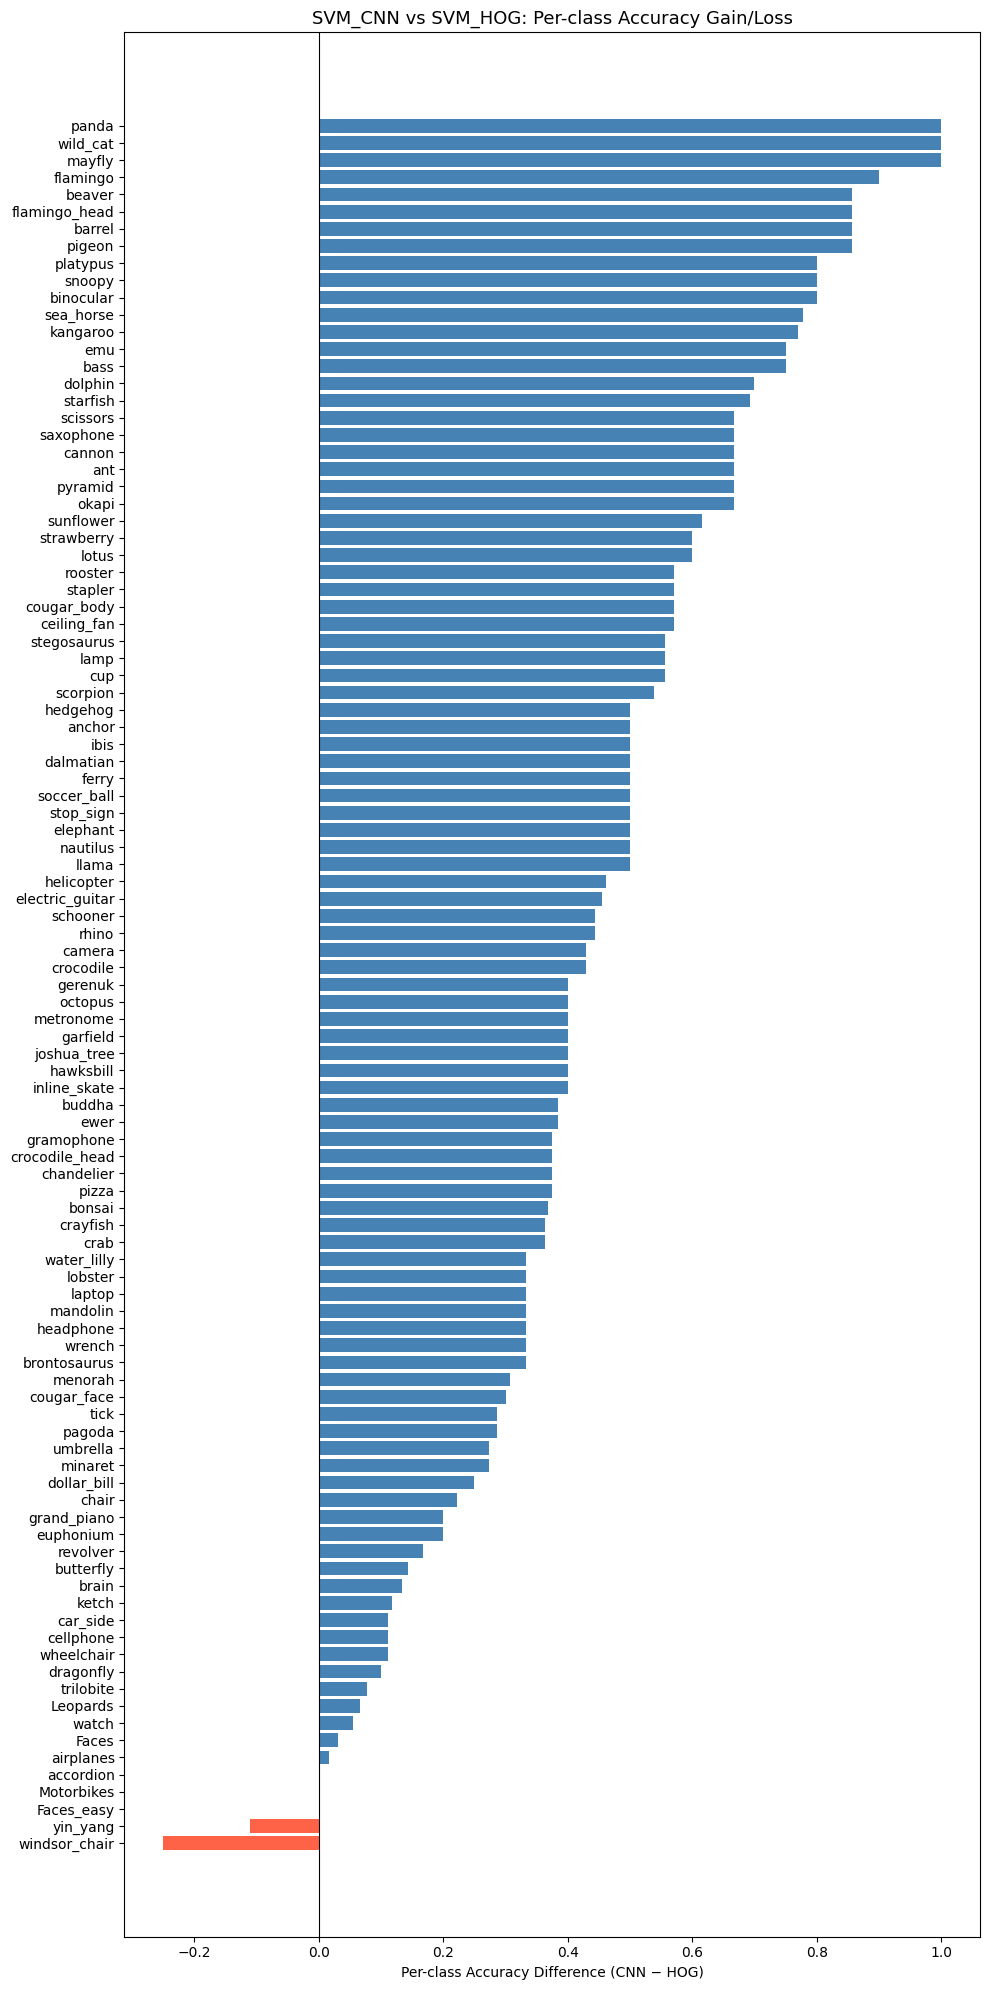

Blue = CNN features better | Red = HOG features better


In [15]:
# ── Per-class accuracy bar chart: SVM_HOG vs SVM_CNN ──────────────────────────
# Visualizes which classes benefit most from CNN features over HOG
hog_acc = [eval_results["SVM_HOG"]["metrics"]["per_class_acc"][c] for c in class_names]
cnn_acc = [eval_results["SVM_CNN"]["metrics"]["per_class_acc"][c] for c in class_names]
diff    = np.array(cnn_acc) - np.array(hog_acc)  # positive = CNN better

# Sort by difference for readability
sorted_idx   = np.argsort(diff)
sorted_names = [class_names[i] for i in sorted_idx]
sorted_diff  = diff[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 20))
colors  = ["tomato" if d < 0 else "steelblue" for d in sorted_diff]
ax.barh(sorted_names, sorted_diff, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Per-class Accuracy Difference (CNN − HOG)")
ax.set_title("SVM_CNN vs SVM_HOG: Per-class Accuracy Gain/Loss", fontsize=13)
plt.tight_layout()
plt.savefig("classical_ml_cnn_vs_hog_perclass.png", dpi=100, bbox_inches="tight")
plt.show()
print("Blue = CNN features better | Red = HOG features better")

In [16]:
# ── Save results for final report ──────────────────────────────────────────────
report_data = {
    name: {
        "y_true" : res["y_true"],
        "y_pred" : res["y_pred"],
        "metrics": res["metrics"],
    }
    for name, res in eval_results.items()
}

with open("classical_ml_results.pkl", "wb") as f:
    pickle.dump(report_data, f)

print("✅ classical_ml_results.pkl saved — will be used in the final report.")
print("\nShare the ablation table above and confirm before we write the final report!")

✅ classical_ml_results.pkl saved — will be used in the final report.

Share the ablation table above and confirm before we write the final report!
